# DAV LAB ASSIGNMENT - 1


## Enroll no: 2503A52142
## Name: k.spurthi


In [ ]:
import pandas as pd

df = pd.read_csv("earthquake_1995-2023.csv")

print("Rows and columns :", df.shape)
df.head()           # show the first 5 rows

Rows and columns : (1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


**Conclusion:**

The earthquake dataset was successfully loaded using Pandas. The dataset contains 1,000 records and 19 attributes. The first five records were displayed to understand the structure and contents of the dataset.

### Dataset Structure and Information

In [ ]:
#.info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   str    
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   str    
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    str    
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   str    
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   str    
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    str    
 17  continent  284 non-null    str    
 18  country    651 non-null    str    
dtypes: float64(6), int64(5), str(8)
memory usage: 148.6 KB


**Conclusion**

The df.info() function shows that the earthquake dataset contains 1,000 entries and 19 columns. The dataset consists of 6 float64, 5 int64, and 8 string columns. Missing values are present mainly in the alert, location, continent, and country columns. This information helps us understand the dataset structure and identify columns that require further data cleaning.

### Checking for Exact Duplicate Rows

In [ ]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


**Conclusion:**

The dataset was checked for exact duplicate rows using df.duplicated(). The result was 0, indicating that there are no completely identical rows in the dataset.

### Identifying Duplicate Records Using Title and Date-Time

In [ ]:
dupe_mask = df.duplicated(subset=["title", "date_time"], keep=False)

print("Rows involved in a title + date_time duplicate:", dupe_mask.sum())

print(df[dupe_mask][["title", "date_time"]])

Rows involved in a title + date_time duplicate: 4
                                   title         date_time
67  M 6.5 - 71 km SE of Nikolski, Alaska  11-01-2022 12:39
68  M 6.5 - 71 km SE of Nikolski, Alaska  11-01-2022 12:39
70  M 6.7 - 91 km SE of Nikolski, Alaska  11-01-2022 11:35
71  M 6.7 - 91 km SE of Nikolski, Alaska  11-01-2022 11:35


**Conclusion:**

Duplicate records were checked using the combination of title and date_time. The analysis identified 4 rows involved in duplicate groups. These records represent repeated earthquake entries with the same title and date-time.

### Removing Duplicate Records

In [ ]:
before = len(df)

df = df.drop_duplicates(subset=["title", "date_time"])

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 1000
Rows after removing duplicates: 998
Duplicates removed: 2


**Conclusion:**

Duplicate records based on title and date_time were successfully removed. The dataset was reduced from 1,000 rows to 998 rows, resulting in 2 duplicate rows being removed.

### Identifying Missing Values in the Dataset

In [ ]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_report)

           Missing Count  Missing Percentage
title                  0            0.000000
magnitude              0            0.000000
date_time              0            0.000000
cdi                    0            0.000000
mmi                    0            0.000000
alert                549           55.010020
tsunami                0            0.000000
sig                    0            0.000000
net                    0            0.000000
nst                    0            0.000000
dmin                   0            0.000000
gap                    0            0.000000
magType                0            0.000000
depth                  0            0.000000
latitude               0            0.000000
longitude              0            0.000000
location               6            0.601202
continent            714           71.543086
country              347           34.769539


**Conclusion:**

The missing-value analysis shows that missing values are present in the alert, location, continent, and country columns. The continent column has the highest missing values with 714, followed by alert with 549 and country with 347. The location column has only 6 missing values.

### Detecting Zero Values in Numerical Columns

In [ ]:
numeric_columns = ["cdi", "gap", "nst", "dmin"]

for col in numeric_columns:
    print("\n", col)
    print("Number of zeros:", (df[col] == 0).sum())


 cdi
Number of zeros: 395

 gap
Number of zeros: 252

 nst
Number of zeros: 519

 dmin
Number of zeros: 586


**Conclusion:**

Zero values were identified in the selected numerical columns. The number of zeros is 395 in cdi, 252 in gap, 519 in nst, and 586 in dmin. These zero values may represent unavailable or missing information and therefore require appropriate treatment.

### Converting Zero Values to NaN

In [ ]:
import numpy as np

for col in numeric_columns:
    df[col] = df[col].replace(0, np.nan)

print("Zeros converted to NaN.")

Zeros converted to NaN.


**Conclusion:**

The zero values in the selected numerical columns were successfully replaced with NaN. This converts the zero values into missing values so they can be handled appropriately during further data-cleaning and analysis.

### Verifying Converted Missing Values

In [ ]:
print(df[numeric_columns].isnull().sum())

cdi     395
gap     252
nst     519
dmin    586
dtype: int64


**Conclusion:**

The conversion was successfully verified. The resulting missing-value counts are 395 for cdi, 252 for gap, 519 for nst, and 586 for dmin. This confirms that all detected zero values in the selected columns were successfully converted to NaN.

Mean medainn mode

Matplotlib is building the font cache; this may take a moment.



Column: gap
Skewness: 4.885701324053703


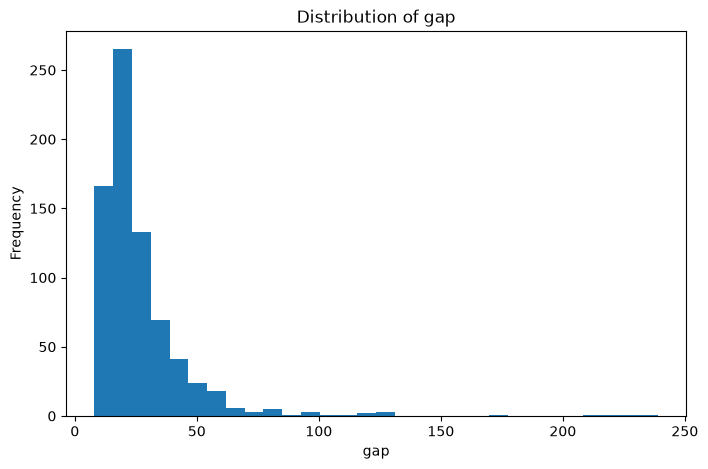


Column: dmin
Skewness: 1.9997583308140012


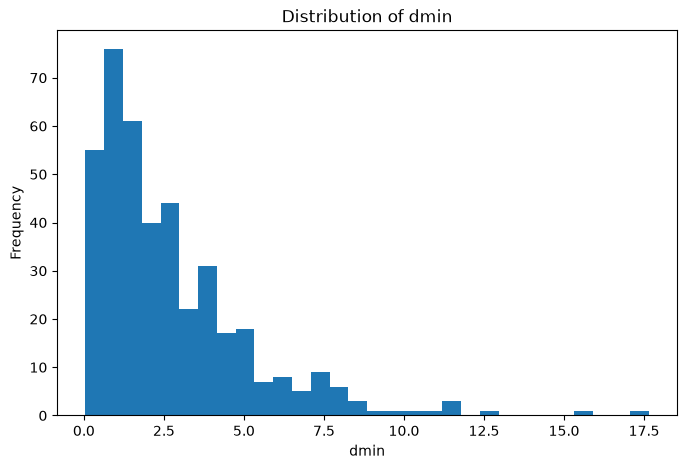

In [ ]:
import matplotlib.pyplot as plt

columns_to_check = ["gap", "dmin"]

for col in columns_to_check:

    print("\nColumn:", col)
    print("Skewness:", df[col].skew())

    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title("Distribution of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
# Example: median for skewed data
df["gap"] = df["gap"].fillna(df["gap"].median())

# Example: mean for approximately symmetric data
df["dmin"] = df["dmin"].fillna(df["dmin"].mean())

In [ ]:
print("Missing alert values:", df["alert"].isnull().sum())

df["alert"] = df["alert"].fillna(df["alert"].mode()[0])

Missing alert values: 549


In [ ]:
df["location"] = df["location"].fillna("Unknown")

In [ ]:
print(df.isnull().sum())

title          0
magnitude      0
date_time      0
cdi          395
mmi            0
alert          0
tsunami        0
sig            0
net            0
nst          519
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       0
continent    714
country      347
dtype: int64


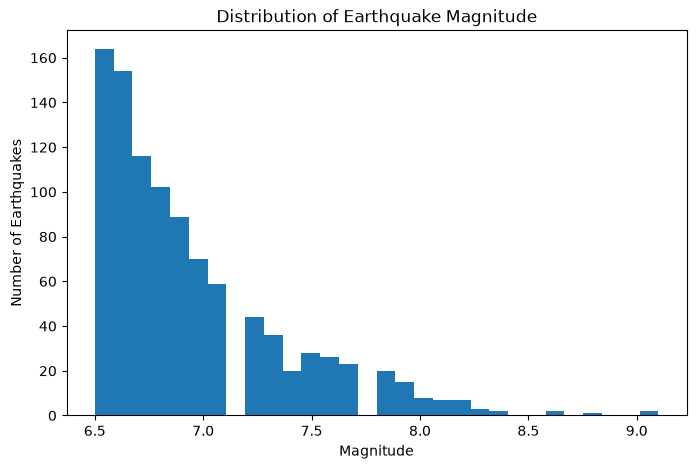

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["magnitude"].dropna(), bins=30)

plt.title("Distribution of Earthquake Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")

plt.show()

In [ ]:
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
title          0
magnitude      0
date_time      0
cdi          395
mmi            0
alert          0
tsunami        0
sig            0
net            0
nst          519
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       0
continent    714
country      347
dtype: int64


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 1975
